# QED-C Benchmarks - Modularized
This notebook shows the three-part modularized benchmark flow: **Part 1** (problem generation), **Part 2** (execution), and **Part 3** (analysis and visualization).

All three parts use QED-C defaults. This is the baseline modularized notebook. The variant notebooks show how to substitute custom code for individual parts:
- **IBM** variant: custom Part 2 (execution on IBM hardware)
- **IQM** variant: custom Part 2 (execution on IQM hardware)
- **MQT** variant: custom Part 1 (circuit generation from MQT Bench)

Configure and run the cell below with the desired settings, then proceed to run the remaining cells.

In [1]:
min_qubits=2
max_qubits=6
skip_qubits=1
max_circuits=3
num_shots=1000

## Part 1: Problem Generation

Utilizing the new **_get_circuits_** flag in the architecture, we can supress execution and obtain only the problem generation components of interest.

The code below grabs the Bernstein-Vazirani Method 1 circuits and any metadata associated with them.

In [2]:
from qedcbench.bernstein_vazirani import bv_benchmark

circuits, metadata = bv_benchmark.get_circuits(
    min_qubits=min_qubits, max_qubits=max_qubits, skip_qubits=skip_qubits,
    max_circuits=max_circuits, method=1
)

print(f"\nCircuits:\n{circuits}")
print(f"\nMetadata: \n{metadata}")

************
Creating [3] circuits with num_qubits = 3
************
Creating [3] circuits with num_qubits = 4
************
Creating [3] circuits with num_qubits = 5
************
Creating [3] circuits with num_qubits = 6

Circuits:
{'3': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000163C23D8AD0>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000163C34E8B10>}, '4': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001632C05BF90>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000163C350C250>, '5': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000163C3450B90>}, '5': {'2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000163C34E1FD0>, '7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000163C35026D0>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000001632C0F24D0>}, '6': {'6': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000162DC03FB90>, '15

### The Circuits and Metadata
Note the format of the outputs:
- **circuits**: dict[str, dict[str, QuantumCircuit]] 
- **metadata**: dict[str, dict[str, dict[str, float]] | str]

Where 
1. The **first dictionary's key** represents the **number of qubits** for the group. In _metadata_, it may also serve as the subtitle.
2. The **second dictionary's key** represents the **unique identifier** for a circuit in the group. This may be a secret string for Bernstein-Vazirani, theta value for Phase-Estimation, and so on. Benchmark specific documentation can be found in our repository.
3. The **third dictionary's key** represents the **metric being stored** in _metadata_. (There is no third dictionary in _circuits_).

## Part 2: Execution

Now that we have the Qiskit circuits, we are free to run them using any execution framework that supports Qiskit!

### Preprocessing and Additional Metrics
We first convert the _circuits_ dictionary into a flat list; additionally, we choose to compute additional metrics and store them in the metrics module.

In [3]:
import time
from qedclib import metrics
import execute as ex

metadata.pop("subtitle", None)
metrics.circuit_metrics = metadata

# Compute gate counts and circuit depth, algorithmic and normalized
ex.compute_all_circuit_metrics(circuits)

# Flatten for direct execution
flat_circuits = [circuits[nq][cid] for nq in circuits if isinstance(circuits[nq], dict) for cid in circuits[nq]]

print(f"Flat Circuits ({len(flat_circuits)})")
print(f"\nAdditional Metrics: \n{metrics.circuit_metrics}")

C:\Users\m\.conda\envs\qiskit-test-2.0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Flat Circuits (11)

Additional Metrics: 
{'3': {'1': {'create_time': 0.0313, 'depth': 6, 'size': 11, 'xi': 0.111, 'n2q': 1, 'tr_depth': 6, 'tr_size': 13, 'tr_xi': 0.091, 'tr_n2q': 1}, '2': {'create_time': 0.0, 'depth': 6, 'size': 11, 'xi': 0.111, 'n2q': 1, 'tr_depth': 6, 'tr_size': 13, 'tr_xi': 0.091, 'tr_n2q': 1}}, '4': {'1': {'create_time': 0.002, 'depth': 6, 'size': 14, 'xi': 0.091, 'n2q': 1, 'tr_depth': 6, 'tr_size': 18, 'tr_xi': 0.067, 'tr_n2q': 1}, '3': {'create_time': 0.003, 'depth': 7, 'size': 15, 'xi': 0.167, 'n2q': 2, 'tr_depth': 7, 'tr_size': 19, 'tr_xi': 0.125, 'tr_n2q': 2}, '5': {'create_time': 0.0025, 'depth': 7, 'size': 15, 'xi': 0.167, 'n2q': 2, 'tr_depth': 7, 'tr_size': 19, 'tr_xi': 0.125, 'tr_n2q': 2}}, '5': {'2': {'create_time': 0.0, 'depth': 6, 'size': 17, 'xi': 0.077, 'n2q': 1, 'tr_depth': 6, 'tr_size': 23, 'tr_xi': 0.053, 'tr_n2q': 1}, '7': {'create_time': 0.0, 'depth': 8, 'size': 19, 'xi': 0.2, 'n2q': 3, 'tr_depth': 8, 'tr_size': 25, 'tr_xi': 0.143, 'tr_n2q': 3},

## Running Circuits

We can choose to run on any execution platform that supports Qiskit circuits; for example, running through qBraid, _pyGSTi_, or a custom platform. 

For the sake of this demonstration, we will execute through a simple simulator.  

In [4]:
# Execute circuits as an array on the simulator.
# Users can replace this cell with any execution framework that supports Qiskit circuits.
from qiskit import transpile
from qiskit_aer import Aer

backend_id = "aer_simulator"
sim = Aer.get_backend(backend_id)
tqc = transpile(flat_circuits, sim)

ts = time.time()
result = sim.run(tqc, shots=num_shots).result()
elapsed_time = time.time() - ts

print(f"Executed {len(flat_circuits)} circuits in {elapsed_time:.3f} secs")

Executed 11 circuits in 0.040 secs


In [5]:
print(result.get_counts())

[{'01': 1000}, {'10': 1000}, {'001': 1000}, {'011': 1000}, {'101': 1000}, {'0010': 1000}, {'0111': 1000}, {'1000': 1000}, {'00110': 1000}, {'01111': 1000}, {'10010': 1000}]


## Part 3: Analysis and Results
After executing the circuits, we can use the counts to compute the fidelities, store them, and plot the results.

### Computing Fidelities
The code below uses the counts from above and stores them in the metrics module, which can then be used to create plots. 

In [6]:
from bernstein_vazirani import bv_benchmark

# Define execution handler: called for each circuit to compute and store fidelity.
def execution_handler(qc, result, num_qubits, circuit_id, num_shots):
    _, fidelity = bv_benchmark.analyze_and_print_result(qc, result, int(num_qubits), int(num_shots),
            s_int=int(circuit_id))
    metrics.store_metric(num_qubits, circuit_id, 'fidelity', fidelity)

# Register the handler and process all circuit results.
# This stores timing metrics and calls execution_handler for each circuit.
ex.init_execution(execution_handler)
ex.process_circuit_results(circuits, result, elapsed_time=elapsed_time, num_shots=num_shots)

# Compute statistics for metrics.
metrics.aggregate_metrics()

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

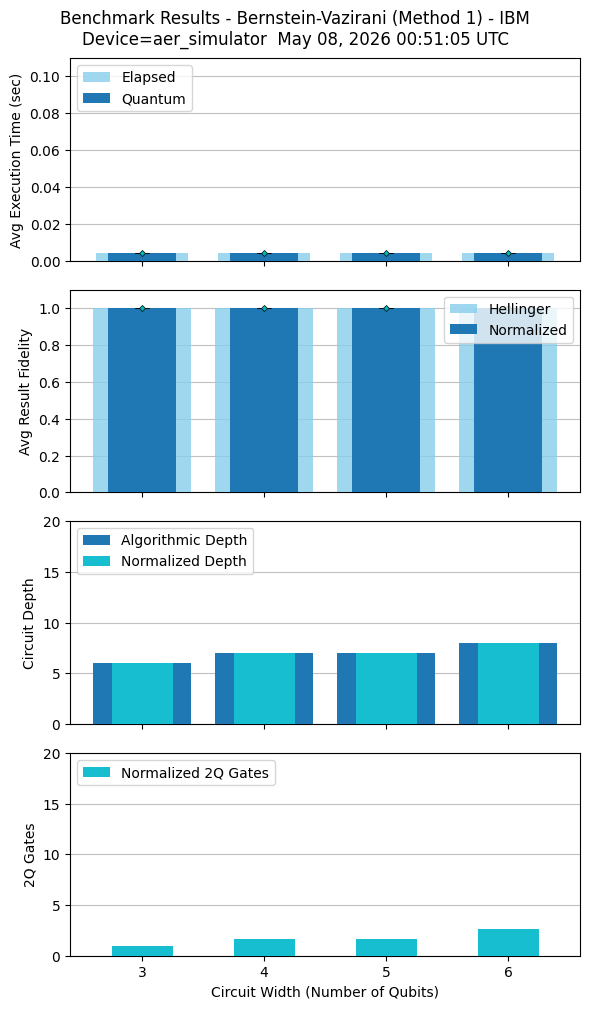

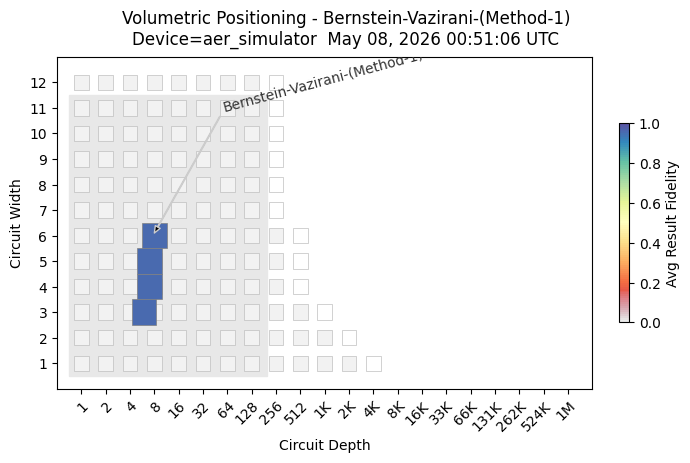

In [7]:
# Set information for plot titles.
benchmark_name = "Bernstein-Vazirani"
provider_name = "IBM"
device_name = "aer_simulator"

# Set plot titles.
benchmark_title = f"{benchmark_name} (Method 1)"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["execute", "fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)